In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

The mean, max, min temp and humd.

Standard deviation for temp.

Graph motion and temp

In [11]:
from urllib.request import urlopen
import json
import time
READ_API_KEY = 'YCW7RBBBL5I33G16' # Change this to your READ_API_KEY
CHANNEL_ID = '3312636' # Change this to your CHANNEL_ID
unoR4 = "https://api.thingspeak.com/channels/"+CHANNEL_ID+"/feeds.json?api_key="+READ_API_KEY
TS = urlopen(unoR4) # Change the URL to your read URL
response = TS.read( ) #Request the url
data = json.loads(response) # Get the response of the web server
feeds = data["feeds"] # The data are here, check it.
# It is also possible to read the values from one fields
field1 = "https://api.thingspeak.com/channels/"+CHANNEL_ID+"/fields/1.json?api_key="+READ_API_KEY
TS_1 = urlopen(unoR4) # Change the URL to your read URL
response_1 = TS_1.read( ) #Request the url
data_1 = json.loads(response_1) # Get the response of the web server
feeds_1 = data_1["feeds"] # The data are here, check it.
df = pd.DataFrame(feeds_1)
cols = {"created_at": "time", "entry_id": "entry_id", "field1": "temperature", "field2": "humidity", "field3": "motion"}
df.rename(columns=cols, inplace=True)
filtered_df = df.loc[df["motion"] == "1.00000"]


In [12]:
df.head()

,time,entry_id,temperature,humidity,motion
0,2026-04-29T09:29:57Z,166,59.00000,25.40000,0.00000
1,2026-04-29T09:30:13Z,167,59.00000,25.30000,0.00000
2,2026-04-29T09:30:29Z,168,59.00000,25.30000,0.00000
3,2026-04-29T09:30:45Z,169,59.00000,25.30000,0.00000
4,2026-04-29T09:31:01Z,170,59.00000,25.20000,0.00000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   time         100 non-null    object
 1   entry_id     100 non-null    int64 
 2   temperature  100 non-null    object
 3   humidity     100 non-null    object
 4   motion       100 non-null    object
dtypes: int64(1), object(4)
memory usage: 4.0+ KB


In [14]:
df = df.apply(lambda col: pd.to_numeric(col) if col.name != 'time' else col)
df['time'] = pd.to_datetime(df['time'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   time         100 non-null    datetime64[ns, UTC]
 1   entry_id     100 non-null    int64              
 2   temperature  100 non-null    float64            
 3   humidity     100 non-null    float64            
 4   motion       100 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(3), int64(1)
memory usage: 4.0 KB


In [15]:
df.describe()

,entry_id,temperature,humidity,motion
count,100.000000,100.000000,100.000000,100.000000
mean,215.500000,59.140000,25.332000,0.110000
std,29.011492,0.376588,0.147628,0.314466
min,166.000000,58.000000,25.100000,0.000000
25%,190.750000,59.000000,25.200000,0.000000
50%,215.500000,59.000000,25.300000,0.000000
75%,240.250000,59.000000,25.400000,0.000000
max,265.000000,60.000000,26.000000,1.000000


<Axes: xlabel='temperature', ylabel='humidity'>

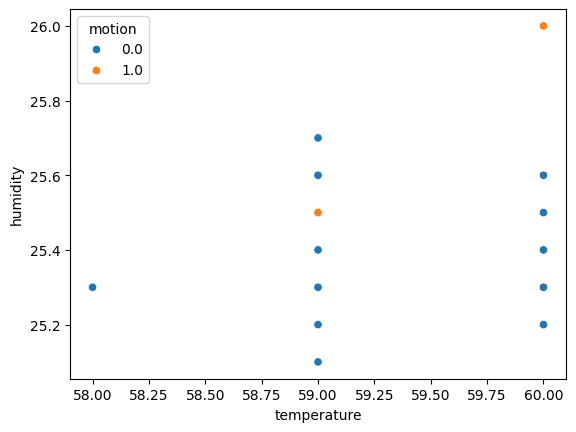

In [19]:
sns.scatterplot(data=df, x='temperature', y='humidity', hue='motion')

<Axes: xlabel='motion', ylabel='Count'>

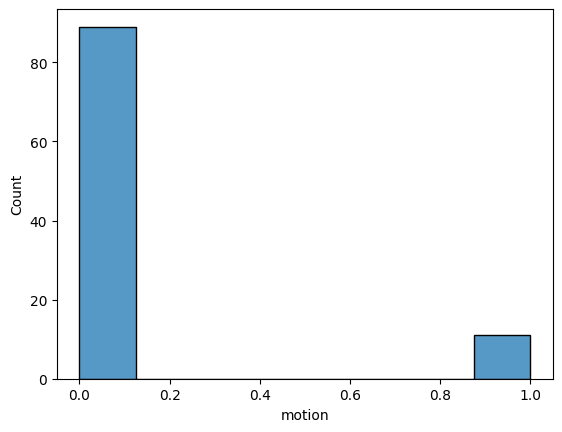

In [21]:
sns.histplot(data=df, x='motion')

<Axes: xlabel='time', ylabel='motion'>

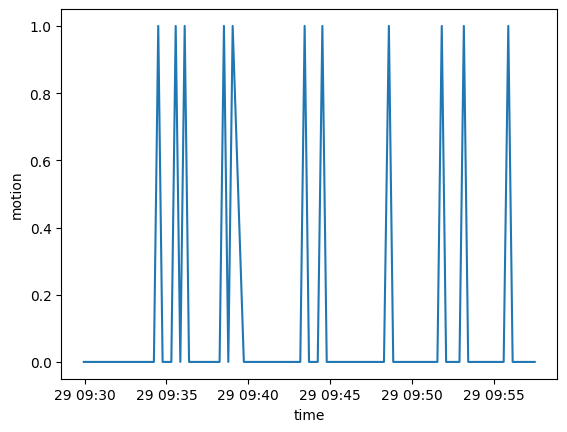

In [23]:
sns.lineplot(data=df, x='time', y='motion')

<Axes: ylabel='temperature'>

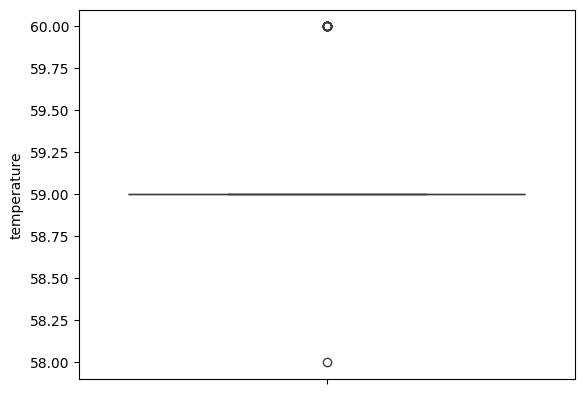

In [25]:
sns.boxplot(data=df, y='temperature')

<Axes: ylabel='humidity'>

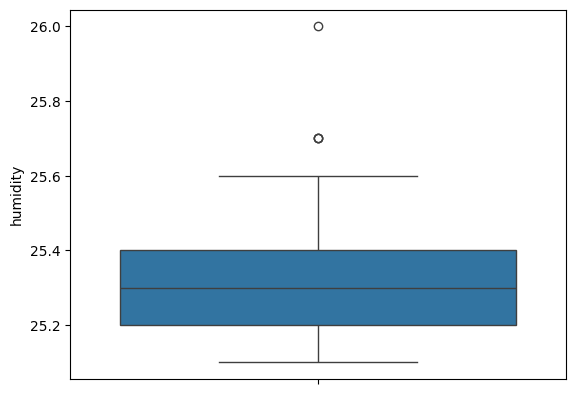

In [27]:
sns.boxplot(data=df, y='humidity')